# 04 - Pitch Type Frequency

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook conducts **Layer 1** of a three-layer analytical framework — examining whether certain pitch types are thrown at meaningfully different rates across MLB ballparks.

Pitch type proportions are computed per park and compared against the league-wide baseline established in `02_eda.ipynb` (Fastball 55.85%, Breaking 29.83%, Offspeed 14.32%). Deviations from that baseline are signal of interest here.

No contact quality or swing outcome data is used in this notebook — only pitch type composition. Outcome and quality layers follow in notebooks 5 and 6.

*Sample*: 173,137 swings across 29 parks (2023–2025 pooled)
<br>
*Granularity*: Park-level pitch type proportions (Level 1 classification of FB, BB, Offspead)
<br>
*Baseline*: League-wide pitch type frequencies from EDA

___
## 1) Setup & Data Load

In [2]:
# Setup

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Database connection ──────────────────────────────────────────────────────
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

# ── Color scheme (project-wide) ──────────────────────────────────────────────
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

In [3]:
# Quick Validation

n_rows  = len(df)
n_parks = df["home_team"].nunique()
parks   = sorted(df["home_team"].unique())

print(f"Rows loaded:  {n_rows:,}")
print(f"Parks loaded: {n_parks}")
print(f"\nParks ({n_parks}):\n{parks}")

# surface any unexpected pitch_category values early
print(f"\nPitch categories present:\n{df['pitch_category'].value_counts()}")

Rows loaded:  173,137
Parks loaded: 29

Parks (29):
['ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']

Pitch categories present:
pitch_category
Fastball    96689
Breaking    51650
Offspeed    24798
Name: count, dtype: int64


___
## 2) League-Wide Baseline (Reference Point)

In [ ]:
# recompute from sample rather than hard-coding

league_counts = df["pitch_category"].value_counts()
league_props  = df["pitch_category"].value_counts(normalize=True)

league_baseline = pd.DataFrame({
    "n":          league_counts,
    "proportion": league_props,
    "pct":        league_props * 100,
}).loc[["Fastball", "Breaking", "Offspeed"]] 

print(f"League-Wide Baseline  (n = {len(df):,})\n")
print(league_baseline.to_string())

League-Wide Baseline  (n = 173,137)

                    n  proportion        pct
pitch_category                              
Fastball        96689    0.558454  55.845371
Breaking        51650    0.298319  29.831867
Offspeed        24798    0.143228  14.322762


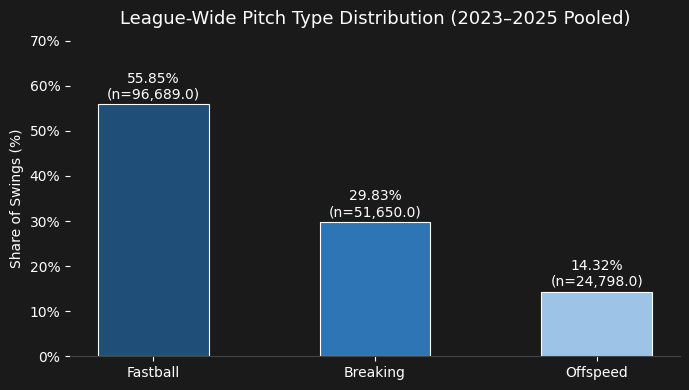

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    league_baseline.index,
    league_baseline["pct"],
    color=[COLORS[c] for c in league_baseline.index],
    width=0.5,
    edgecolor="white",
    linewidth=0.8,
)

# label each bar with percentage
for i, (cat, row) in enumerate(league_baseline.iterrows()):
    ax.text(
        i, row["pct"] + 0.5,
        f"{row['pct']:.2f}%\n(n={row['n']:,})",
        ha="center", va="bottom",
        fontsize=10, color="white"
    )

ax.set_title("League-Wide Pitch Type Distribution (2023–2025 Pooled)", 
             fontsize=13, pad=12, color="white")
ax.set_ylabel("Share of Swings (%)", color="white")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 70)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#444444")

plt.tight_layout()
plt.show()

___
## 3) Park-Level Pitch Type Proportions (Level 1)

In [11]:
# count swings per park per pitch category, then normalize within each park
park_counts = (
    df.groupby(["home_team", "pitch_category"])
    .size()
    .unstack(fill_value=0)
    [["Fastball", "Breaking", "Offspeed"]]  # enforce column order
)

park_props = park_counts.div(park_counts.sum(axis=1), axis=0)
park_n     = park_counts.sum(axis=1).rename("n")

# attach n to props for reporting
park_summary = park_props.copy()
park_summary.insert(0, "n", park_n)

print(f"Park-Level Pitch Type Proportions  (n per park ≈ 5,970)\n")

display_summary = park_summary.copy()
display_summary[["Fastball", "Breaking", "Offspeed"]] = (
    display_summary[["Fastball", "Breaking", "Offspeed"]] * 100
).round(2)
display_summary["n"] = display_summary["n"].astype(int)
print(display_summary.to_string())

Park-Level Pitch Type Proportions  (n per park ≈ 5,970)

pitch_category     n  Fastball  Breaking  Offspeed
home_team                                         
ATL             5927     52.45     34.22     13.33
AZ              5996     55.47     29.44     15.09
BAL             5957     55.95     27.18     16.87
BOS             5955     56.88     29.50     13.62
CHC             5910     57.34     29.54     13.11
CIN             5953     56.19     29.11     14.70
CLE             5970     55.66     28.66     15.68
COL             5994     53.75     32.43     13.81
CWS             5964     55.52     31.22     13.26
DET             5965     54.10     29.12     16.78
HOU             5978     54.60     32.84     12.56
KC              5948     52.27     32.67     15.06
LAA             5973     53.94     29.11     16.94
LAD             5988     55.68     31.66     12.66
MIA             5998     54.18     30.99     14.82
MIL             5903     62.10     26.21     11.69
MIN             6000     

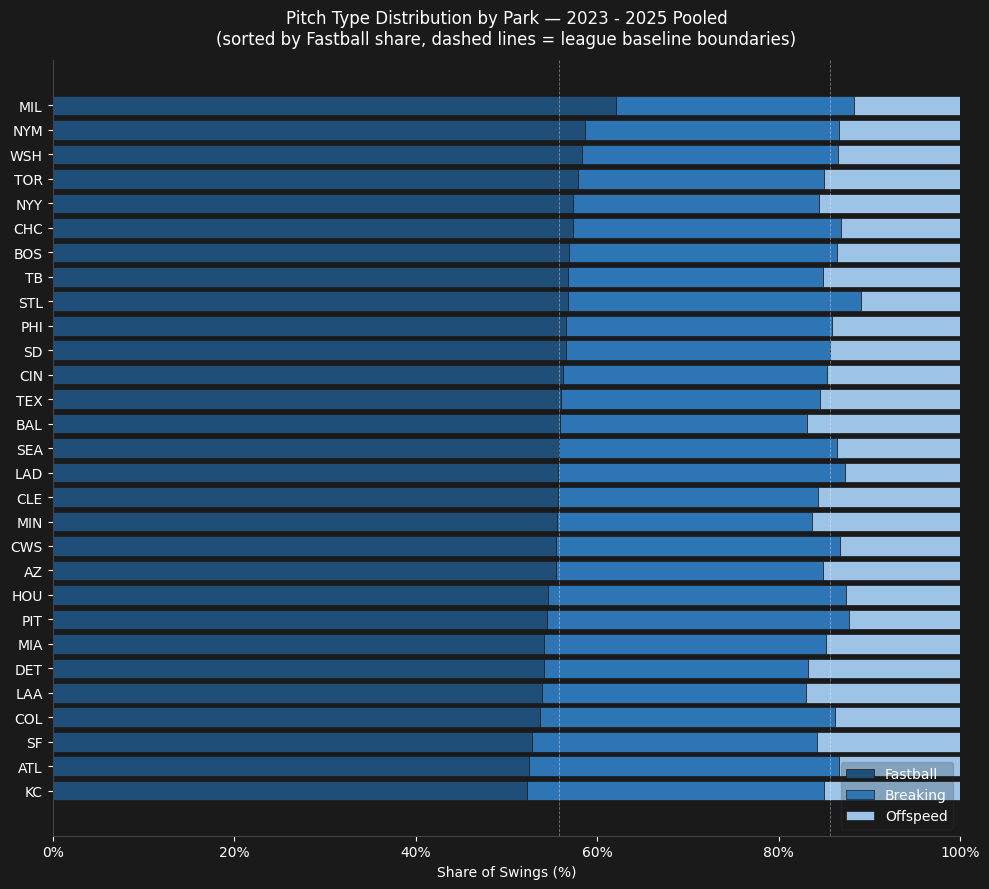

In [ ]:
# Sort parks by fastball proportion descending — most fastball-heavy parks on top
park_props_sorted = park_props.sort_values("Fastball", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

left = np.zeros(len(park_props_sorted))
for cat in ["Fastball", "Breaking", "Offspeed"]:
    values = park_props_sorted[cat].values * 100
    bars = ax.barh(
        park_props_sorted.index,
        values,
        left=left,
        color=COLORS[cat],
        label=cat,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    left += values

# Lines that reference the league baselines
for i, cat in enumerate(["Fastball", "Breaking", "Offspeed"]):
    cumulative = league_baseline.loc[["Fastball", "Breaking", "Offspeed"][:i+1], "pct"].sum()
    ax.axvline(cumulative, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

ax.set_xlabel("Share of Swings (%)", color="white")
ax.set_title("Pitch Type Distribution by Park — 2023 - 2025 Pooled\n(sorted by Fastball share, dashed lines = league baseline boundaries)", 
             fontsize=12, pad=12, color="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

ax.legend(
    loc="lower right",
    framealpha=0.2,
    labelcolor="white",
    facecolor="#1a1a1a",
    edgecolor="#444444",
)

plt.tight_layout()
plt.show()

___
## 4) Deviation from Baseline

In [ ]:
# subtracting league baseline from each park's proportions
# positive = park throws that type more than league average, negative indicates less
baseline_props = league_baseline["proportion"]

park_deviations = park_props.subtract(baseline_props, axis=1) * 100  # expressed in percentage points

print("Deviation from League Baseline (percentage points)\n")
print(park_deviations.sort_values("Fastball", ascending=False).round(2).to_string())

Deviation from League Baseline (percentage points)

pitch_category  Fastball  Breaking  Offspeed
home_team                                   
MIL                 6.26     -3.62     -2.63
NYM                 2.76     -1.77     -0.98
WSH                 2.43     -1.57     -0.86
TOR                 2.08     -2.73      0.65
NYY                 1.51     -2.79      1.28
CHC                 1.50     -0.29     -1.21
BOS                 1.03     -0.33     -0.70
TB                  0.97     -1.74      0.78
STL                 0.90      2.46     -3.36
PHI                 0.77     -0.53     -0.24
SD                  0.68     -0.71      0.04
CIN                 0.34     -0.72      0.38
TEX                 0.20     -1.37      1.17
BAL                 0.11     -2.65      2.55
SEA                -0.06      0.75     -0.70
LAD                -0.17      1.83     -1.66
CLE                -0.18     -1.17      1.36
MIN                -0.28     -1.68      1.96
CWS                -0.33      1.39     -1.06
AZ 

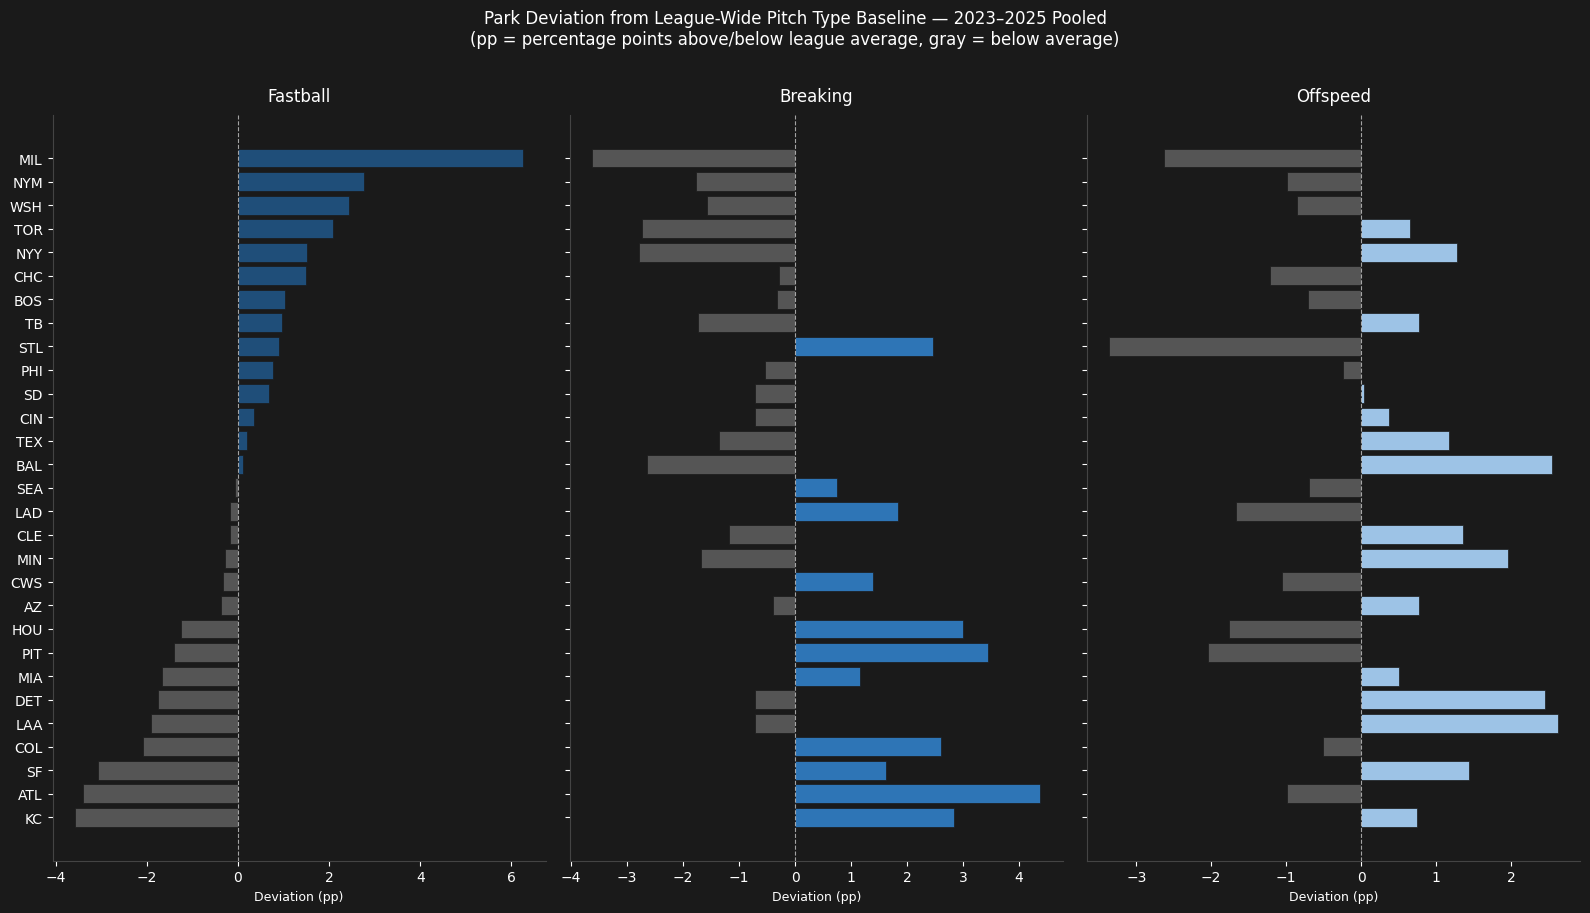

In [ ]:
# Sort by fastball deviation — puts Milwaukee at top and confirms visual from Section 3
dev_sorted = park_deviations.sort_values("Fastball", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

for ax, cat in zip(axes, ["Fastball", "Breaking", "Offspeed"]):
    values = dev_sorted[cat]
    colors = [COLORS[cat] if v > 0 else "#555555" for v in values]
    
    ax.barh(
        dev_sorted.index,
        values,
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(cat, color="white", fontsize=12, pad=10)
    ax.set_xlabel("Deviation (pp)", color="white", fontsize=9)
    ax.tick_params(colors="white")
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Park Deviation from League-Wide Pitch Type Baseline — 2023–2025 Pooled\n(pp = percentage points above/below league average, gray = below average)",
    color="white", fontsize=12, y=1.01
)

plt.tight_layout()
plt.show()

___
## 5) Statistical Significance

Chi-Square GOF test for each park against league distribution

In [14]:
from scipy.stats import chisquare

# expected proportions from league baseline
expected_props = baseline_props[["Fastball", "Breaking", "Offspeed"]].values

results = []
for park in park_counts.index:
    observed = park_counts.loc[park, ["Fastball", "Breaking", "Offspeed"]].values
    n = observed.sum()
    expected = expected_props * n  # scale to park sample size
    
    chi2, p = chisquare(f_obs=observed, f_exp=expected)
    
    results.append({
        "park":      park,
        "n":         n,
        "chi2":      round(chi2, 3),
        "p_value":   round(p, 4),
        "significant": p < 0.05,
    })

chi2_results = (
    pd.DataFrame(results)
    .set_index("park")
    .sort_values("chi2", ascending=False)
)

print("Chi-Square Goodness-of-Fit — Park vs. League Baseline\n")
print(chi2_results.to_string())

Chi-Square Goodness-of-Fit — Park vs. League Baseline

         n    chi2  p_value  significant
park                                    
MIL   5903  95.994   0.0000         True
STL   5992  60.209   0.0000         True
ATL   5927  54.481   0.0000         True
PIT   6000  43.525   0.0000         True
BAL   5957  41.080   0.0000         True
LAA   5973  33.532   0.0000         True
HOU   5978  32.687   0.0000         True
KC    5948  31.919   0.0000         True
DET   5965  29.443   0.0000         True
NYY   5999  25.022   0.0000         True
SF    5966  23.890   0.0000         True
MIN   6000  21.875   0.0000         True
TOR   5999  21.360   0.0000         True
COL   5994  19.368   0.0001         True
NYM   5998  18.547   0.0001         True
LAD   5988  18.340   0.0001         True
WSH   5948  14.230   0.0008         True
CLE   5970  10.444   0.0054         True
TB    5981   9.602   0.0082         True
TEX   5990   9.521   0.0086         True
CWS   5964   8.649   0.0132         True
CH

In [15]:
sig_count = chi2_results["significant"].sum()
print(f"{sig_count} of 29 parks deviate significantly from league baseline (p < 0.05)")
print(f"{29 - sig_count} parks are statistically indistinguishable from league average")

23 of 29 parks deviate significantly from league baseline (p < 0.05)
6 parks are statistically indistinguishable from league average


___
## 6) Individual Pitch Code Breakdown (Level 2)

___
## 7) Handedness Cut (Metadata Check)

___
## 8) Observations & Forward Look